# Import layers

In [1]:

from torch import nn
from torchvision.datasets import CIFAR10
from torchvision.transforms import v2, functional
import time
import numpy as np
import seaborn as sns
import sys
from pathlib import Path

In [2]:

LCL_PATH  = str(Path().cwd())
ROOT_PATH = str(Path(LCL_PATH).parent.parent.parent)
DEEPL_PATH = str(Path(ROOT_PATH)/"deep_learning")
DS_PATH = "{}/data_visualisation/data".format(ROOT_PATH)

print("""
root path:\t{}
local path:\t{}
deep learning path:\t{}
dataset path:\t{}""".format(ROOT_PATH, LCL_PATH, DEEPL_PATH, DS_PATH))

# adding local_folder to the system path
sys.path.append(ROOT_PATH)
sys.path.append(LCL_PATH)
sys.path.append(DEEPL_PATH)

from sys_function import * # este in root


root path:	/home/gheorghe/Desktop/Proiecte/master/CapitoleAvansateDinReteleNeuronale/CARN
local path:	/home/gheorghe/Desktop/Proiecte/master/CapitoleAvansateDinReteleNeuronale/CARN/deep_learning/callback/test
deep learning path:	/home/gheorghe/Desktop/Proiecte/master/CapitoleAvansateDinReteleNeuronale/CARN/deep_learning
dataset path:	/home/gheorghe/Desktop/Proiecte/master/CapitoleAvansateDinReteleNeuronale/CARN/data_visualisation/data


In [21]:

sys_remove_modules("imshow")
sys_remove_modules("dataset.append_help_dataset")
sys_remove_modules("callback.save_image")
sys_remove_modules("checks.tensor_check")

from imshow import *
from dataset.append_help_dataset import *
from callback.save_image import *
from checks.tensor_check import *

In [4]:
IMAGE_SIZE = 32

# Data aquisition

In [5]:

transform = [ # image->tensor->resize->make square-> 
        # if use 'ToImage' tensor should be numpy array!!!
        v2.ToImage(), # data are transorm to torch tensor in Dataset manager, tensor should be numpy array!!!
        v2.Resize(size=int(IMAGE_SIZE),),
        v2.CenterCrop(IMAGE_SIZE),
        v2.ToDtype(torch.float32, scale=False), # scale True normalized
        v2.Normalize(mean=(127.5, 127.5, 127.5), std=(127.5, 127.5, 127.5), inplace=True),
    ]
init_transform = v2.Compose(transform)

In [6]:

transform = [ # image->tensor->resize->make square-> 
        v2.Normalize(mean=(0,), std=(1/127.5,), inplace=False),
        v2.Normalize(mean=(-127.5,), std=(1,), inplace=False),
    ]
out_transform = v2.Compose(transform)

In [7]:

cifar10_test  = CIFAR10(root=DS_PATH, train=False, transform=None, download=True)
print(str(cifar10_test))

meta_cifar10_test  = dict(data_reader=cifar10_test , size=50000, num_classes=10)


Dataset CIFAR10
    Number of datapoints: 10000
    Root location: /home/gheorghe/Desktop/Proiecte/master/CapitoleAvansateDinReteleNeuronale/CARN/data_visualisation/data
    Split: Test


In [8]:

train_ds = AppendHelpDatasets(meta_cifar10_test, help_metads=None, 
                              transform=init_transform, 
                              help_from=0.1)

In [9]:

in_shape  = (3, IMAGE_SIZE, IMAGE_SIZE)
out_shape = ()
for idx in range(1000):
    inputs, _ = train_ds[idx]
    tensor_check(inputs, in_shape, 1, -1, torch.float32, arr_type=None)
else:
    print("OK")

OK


In [10]:

in_shape  = (3, IMAGE_SIZE, IMAGE_SIZE)
out_shape = ()
for idx in range(1000):
    inputs, _ = train_ds[idx]
    inputs = out_transform(inputs)
    tensor_check(inputs, in_shape, 255, 0, torch.float32, arr_type=None)
else:
    print("OK")

OK


In [11]:

in_shape  = (3, IMAGE_SIZE, IMAGE_SIZE)
gray_shape= (1, IMAGE_SIZE, IMAGE_SIZE)
out_shape = (IMAGE_SIZE, IMAGE_SIZE, 1)
# read image
inputs, target = train_ds[0]
tensor_check(inputs, in_shape, 1, -1, torch.float32, arr_type=None)
# cast to gray
inputs = inputs.mean(dim=0)
inputs = torch.unsqueeze(inputs, dim=0)
tensor_check(inputs, gray_shape, 1, -1, torch.float32, arr_type=None)
# apply out transformation
inputs = out_transform(inputs)
tensor_check(inputs, gray_shape, 255, 0, torch.float32, arr_type=None)
# transform to gray image
inputs = torch.permute(inputs, dims=(1, 2, 0)).numpy().astype(np.uint8)
tensor_check(inputs, out_shape, 255, 0, np.uint8, arr_type=None)
image_show_wait(inputs, window_name="Test", height=224)

Key 32


# Build model

In [12]:

class GrayModel(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        x = functional.rgb_to_grayscale(x, num_output_channels=1)
        return x

In [13]:

model = GrayModel()
in_shape  = (3, IMAGE_SIZE, IMAGE_SIZE)
gray_shape= (1, IMAGE_SIZE, IMAGE_SIZE)
out_shape = (IMAGE_SIZE, IMAGE_SIZE, 1)
# read image
inputs, target = train_ds[0]
tensor_check(inputs, in_shape, 1, -1, torch.float32, arr_type=None)
inputs = torch.unsqueeze(inputs, dim=0)
tensor_check(inputs, (1, *in_shape), 1, -1, torch.float32, arr_type=None)
# cast to gray
inputs = model(inputs)
inputs = torch.squeeze(inputs, dim=0)
tensor_check(inputs, gray_shape, 1, -1, torch.float32, arr_type=None)
# apply out transformation
inputs = out_transform(inputs)
tensor_check(inputs, gray_shape, 255, 0, torch.float32, arr_type=None)
# transform to gray image
inputs = torch.permute(inputs, dims=(1, 2, 0)).numpy().astype(np.uint8)
tensor_check(inputs, out_shape, 255, 0, np.uint8, arr_type=None)
image_show_wait(inputs, window_name="Test", height=224)

Key 32


# Build callback

Error prediction, false image: ''SaveGrayImg' object has no attribute '_SaveGrayImg__model''
Error prediction, false image: ''SaveGrayImg' object has no attribute '_SaveGrayImg__model''
Error prediction, false image: ''SaveGrayImg' object has no attribute '_SaveGrayImg__model''
Error prediction, false image: ''SaveGrayImg' object has no attribute '_SaveGrayImg__model''


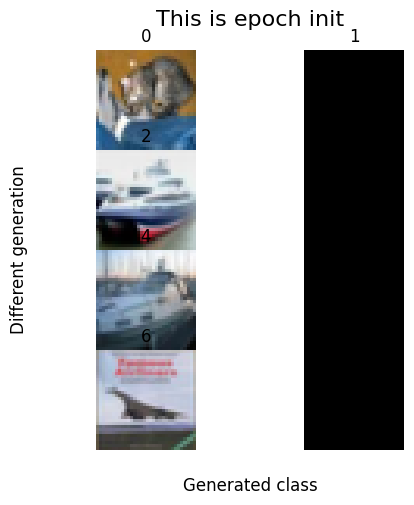

In [22]:

path = "{}/logs".format(LCL_PATH)
callback = SaveGrayImg(train_ds, out_transform, size=4, path=path)
callback.setModel(GrayModel())

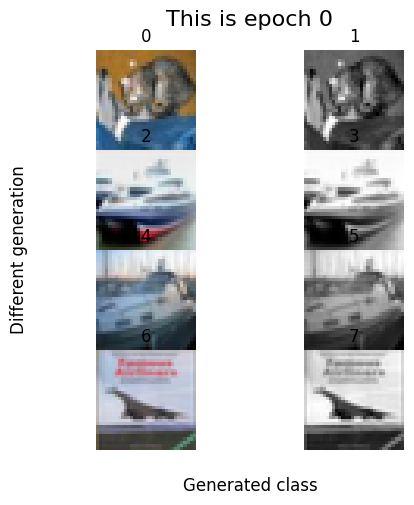

In [23]:

callback.on_epoch_end(0)